**Actividad 1**

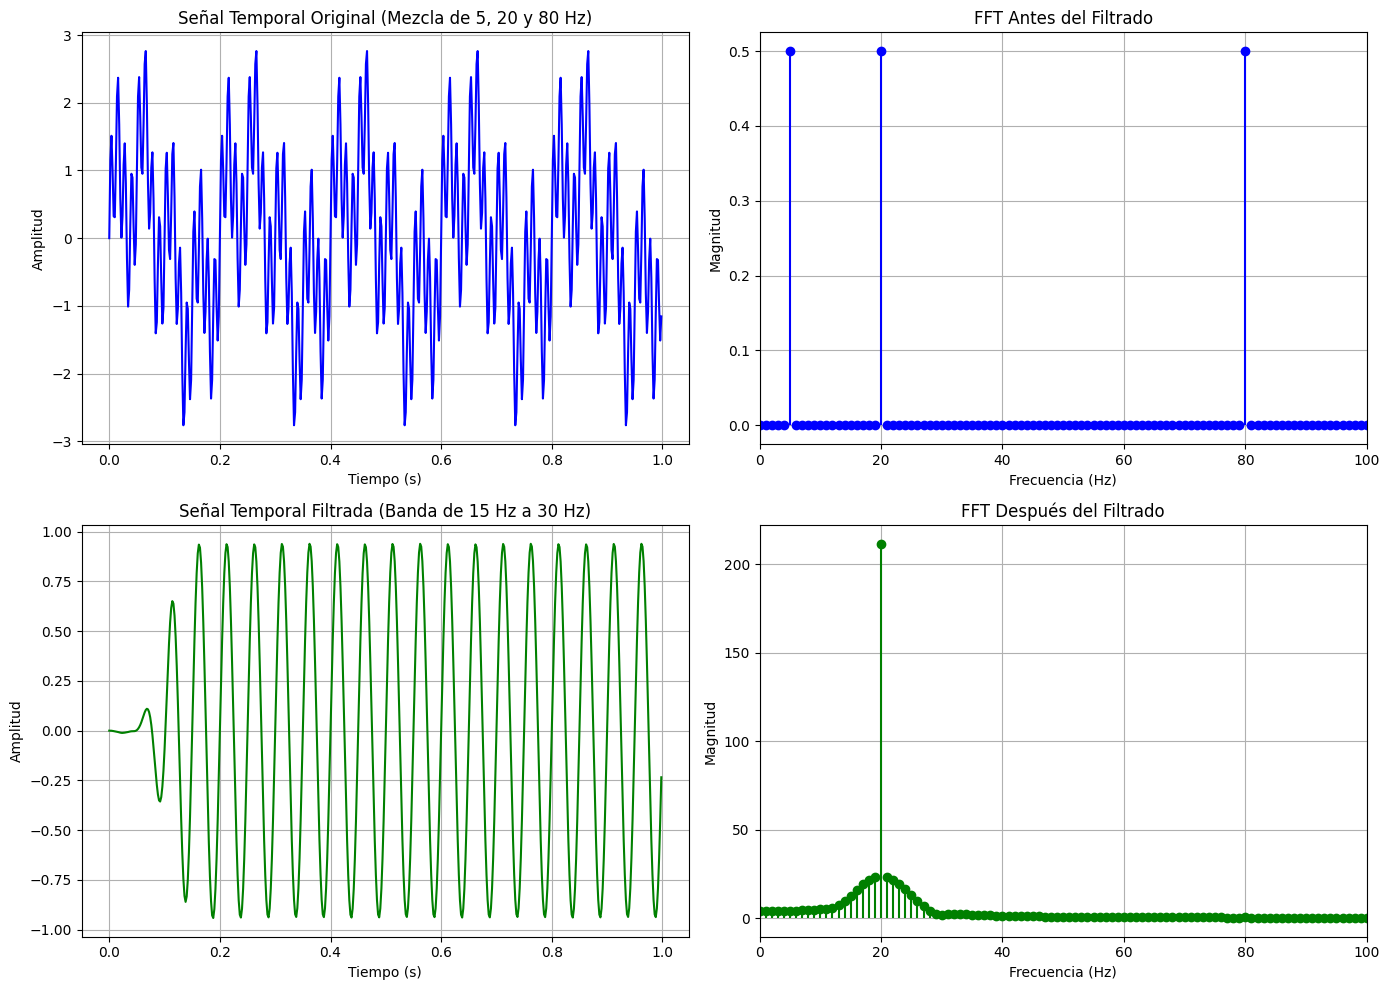

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter

#Muestreo y tiempo para la señal
fs = 500.0
t = np.arange(0, 1, 1/fs)

#Señales con sus respectivas frecuencias
f1, f2, f3 = 5, 20, 80
senal_5hz = np.sin(2 * np.pi * f1 * t)
senal_20hz = np.sin(2 * np.pi * f2 * t)
senal_80hz = np.sin(2 * np.pi * f3 * t)

#Señal combinada
senal_original = senal_5hz + senal_20hz + senal_80hz

#Parametros del filtro FIR
N = 101
#limite inferior
f1 = 15.0
#limite superior
f2 = 30.0

#filtro usando firwin
fir = firwin(
    N,
    [f1, f2],
    pass_zero=False,
    fs=fs
)

#aplicamos el filtro a la señal original
senal_filtrada = lfilter(fir, 1.0, senal_original)

#FFT con funcion fft.rfft
fft_orig = np.abs(np.fft.rfft(senal_original)) / len(senal_original)
fft_filt = np.abs(np.fft.rfft(senal_filtrada))

#frecuencia para el ploteo
frecuencias = np.fft.rfftfreq(len(senal_original), 1/fs)

#mostrar resultados
plt.figure(figsize=(14, 10))

#ANTES DEL FILTRADO
plt.subplot(2, 2, 1)
plt.plot(t, senal_original, color='blue')
plt.title('Señal Temporal Original (Mezcla de 5, 20 y 80 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.stem(frecuencias, fft_orig, linefmt='blue', markerfmt='bo', basefmt=" ")
plt.title('FFT Antes del Filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.grid(True)


#DESPUES DEL FILTRADO
plt.subplot(2, 2, 3)
plt.plot(t, senal_filtrada, color='green')
plt.title('Señal Temporal Filtrada (Banda de 15 Hz a 30 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.stem(frecuencias, fft_filt, linefmt='green', markerfmt='go', basefmt=" ")
plt.title('FFT Después del Filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.grid(True)

plt.tight_layout()
plt.show()

**Actividad 2**

In [2]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 25.9 MB/s eta 0:00:00


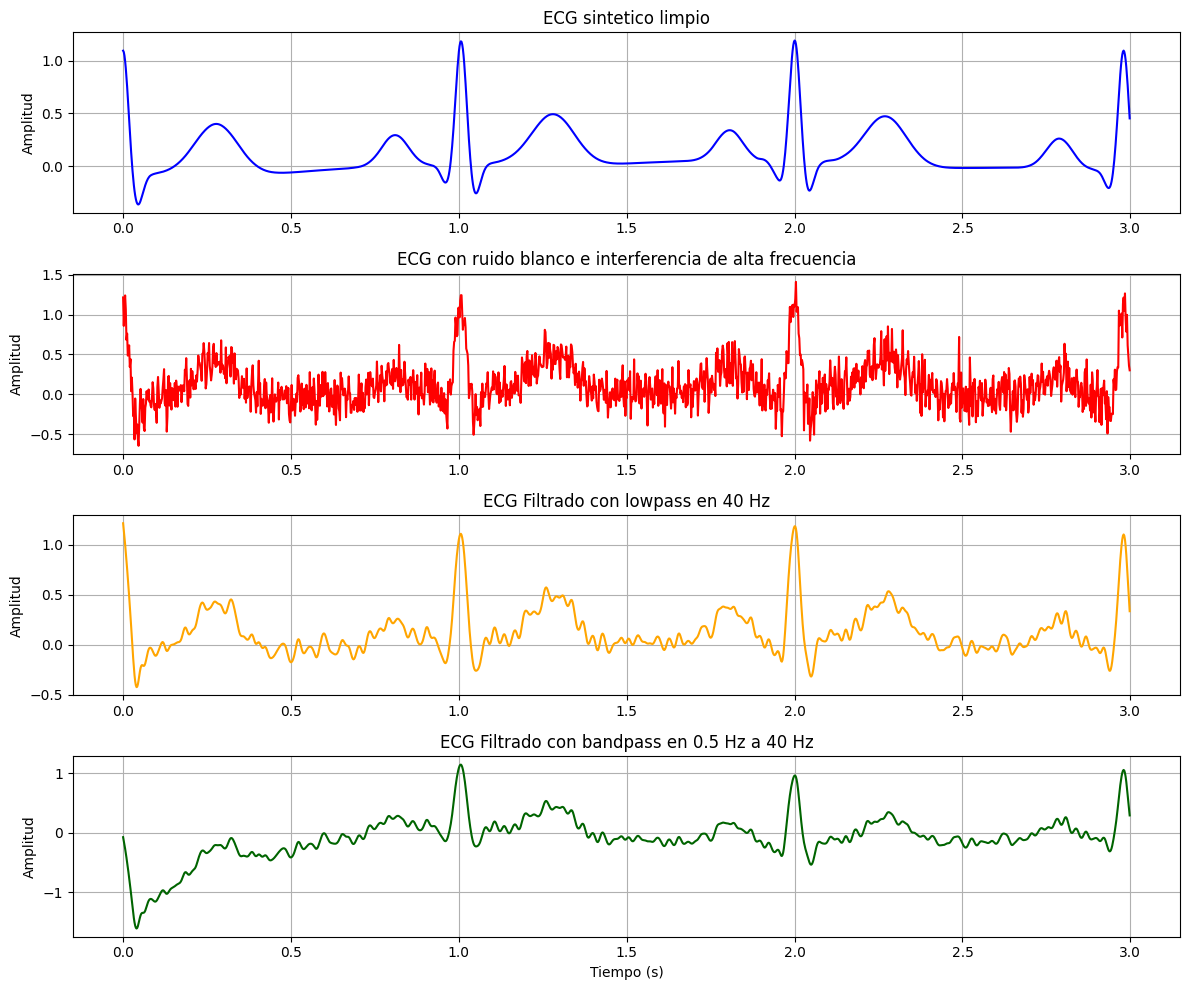

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import butter, filtfilt

#parametros
fs = 500.0
duracion = 10
t = np.arange(0, duracion, 1/fs)

#generamos un ECG sintetico limpio usando NeuroKit2
ecg_limpio = nk.ecg_simulate(duration=duracion, sampling_rate=int(fs), noise=0.0, heart_rate=60)

#generar ruido blanco
ruido_blanco = np.random.normal(0, 0.15, len(ecg_limpio))

#generamos interferencia de alta Frecuencia, para este caso ruido de red de 60 Hz
interferencia_alta = 0.1 * np.sin(2 * np.pi * 60 * t)

#combinamos y obtenemos la señal ECG con ruido e interferencia
ecg_ruidoso = ecg_limpio + ruido_blanco + interferencia_alta

#FILTRO LOWPASS
#cortamos en 40 Hz para eliminar la interferencia de alta frecuencia
f_corte_low = 40.0
b_low, a_low = butter(N=4, Wn=f_corte_low, btype='low', fs=fs)
ecg_filtrado_lowpass = filtfilt(b_low, a_low, ecg_ruidoso)

#FILTRO BANDPASS
#filtramos entre 0.5 Hz y 40 Hz para un ECG correcto
f_baja = 0.5
f_alta = 40.0
b_band, a_band = butter(N=4, Wn=[f_baja, f_alta], btype='bandpass', fs=fs)
ecg_filtrado_bandpass = filtfilt(b_band, a_band, ecg_ruidoso)

muestras_visibles = int(3 * fs)

#mostramos resultados
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t[:muestras_visibles], ecg_limpio[:muestras_visibles], color='blue')
plt.title('ECG sintetico limpio')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(4, 1, 2)
plt.plot(t[:muestras_visibles], ecg_ruidoso[:muestras_visibles], color='red')
plt.title('ECG con ruido blanco e interferencia de alta frecuencia')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t[:muestras_visibles], ecg_filtrado_lowpass[:muestras_visibles], color='orange')
plt.title('ECG Filtrado con lowpass en 40 Hz')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t[:muestras_visibles], ecg_filtrado_bandpass[:muestras_visibles], color='darkgreen')
plt.title('ECG Filtrado con bandpass en 0.5 Hz a 40 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

**Actividad 3**

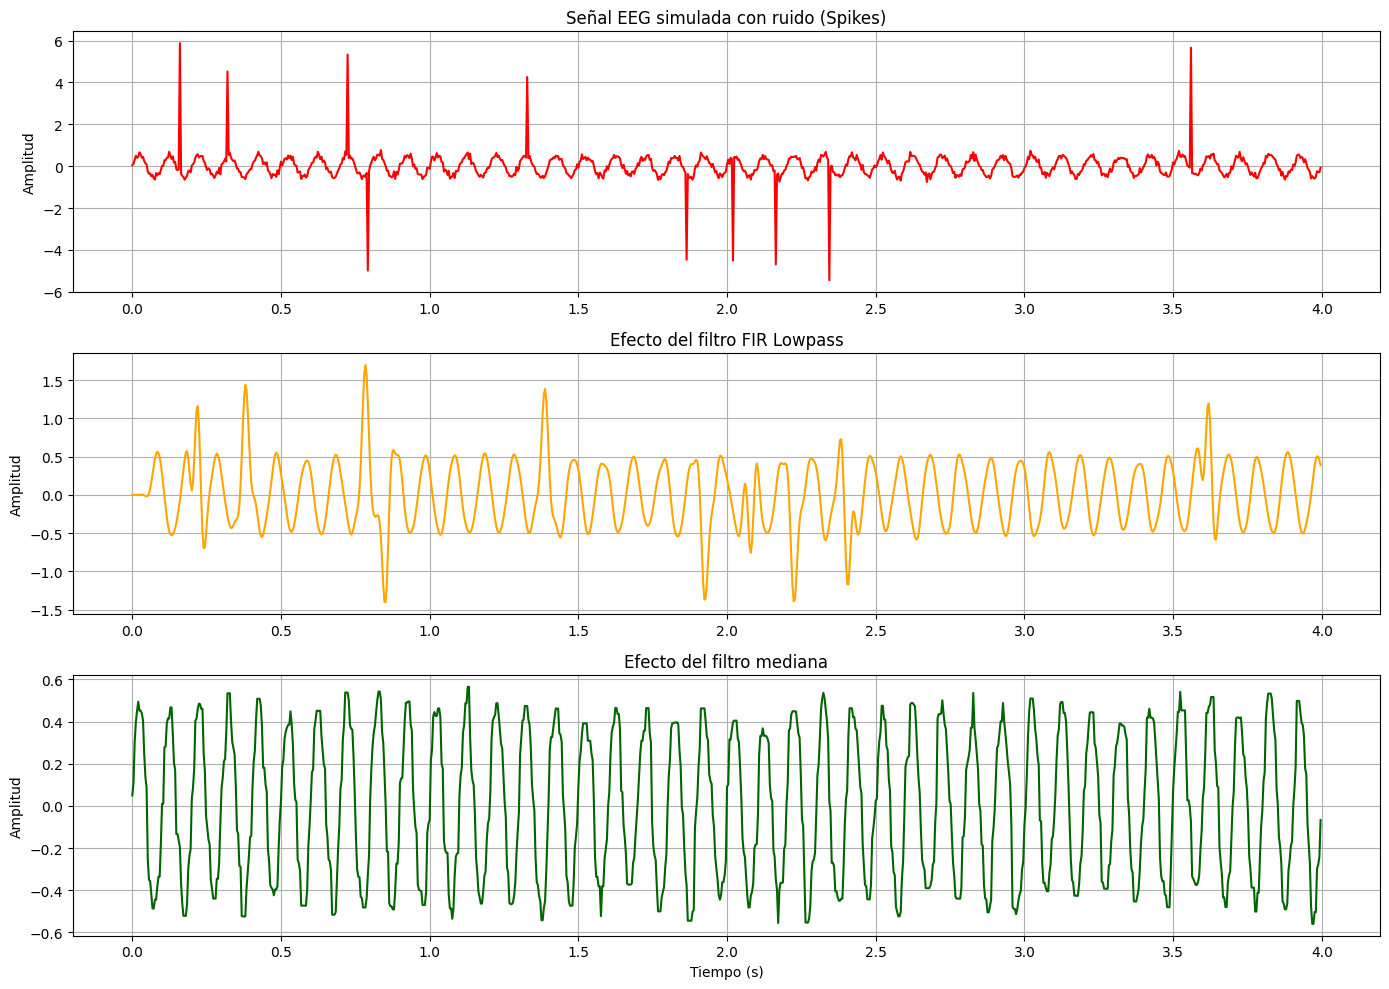

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

#Parametros normales para EEG
fs = 250.0
duracion = 4.0
t = np.arange(0, duracion, 1/fs)
n_muestras = len(t)

#señal EEG simulada
np.random.seed(42)
eeg_base = 0.5 * np.sin(2 * np.pi * 10 * t) + np.random.normal(0, 0.1, n_muestras)

#copiamos la señal base para contaminarla
eeg_con_spikes = eeg_base.copy()

#generamos los 10 valores aleatorios donde ocurriran los picos
indices_spikes = np.random.choice(n_muestras, size=10, replace=False)

#picos aleatorios con amplitud de -5 o 5
for idx in indices_spikes:
    #genera un pico aleatorio que puede ser positivo o negativo
    eeg_con_spikes[idx] = np.random.choice([-5, 5]) * np.random.uniform(0.8, 1.2)

#Filtro FIR Lowpass
#Pasa bajas con corte en 30 Hz
N = 31
f_corte = 30.0
fir_coef = firwin(N, f_corte, pass_zero=True, fs=fs)
eeg_filtrado_fir = lfilter(fir_coef, 1.0, eeg_con_spikes)

#Filtro Mediana
eeg_filtrado_mediana = medfilt(eeg_con_spikes,5)


plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(t, eeg_con_spikes, color='red')
plt.title('Señal EEG simulada con ruido (Spikes)')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(3, 1, 2)
plt.plot(t, eeg_filtrado_fir, color='orange')
plt.title('Efecto del filtro FIR Lowpass')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(3, 1, 3)
plt.plot(t, eeg_filtrado_mediana, color='darkgreen')
plt.title('Efecto del filtro mediana')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)


plt.tight_layout()
plt.show()

Se observa que el filtro mediana funciona mucho mejor ya que al ordenar los datos de la ventana de forma ascendente y seleccionar el valor central, descarta por completo los picos reemplazándolos por valores vecinos realistas de la señal EEG original sin deformarla ni atenuarla.

**Actividad 4**

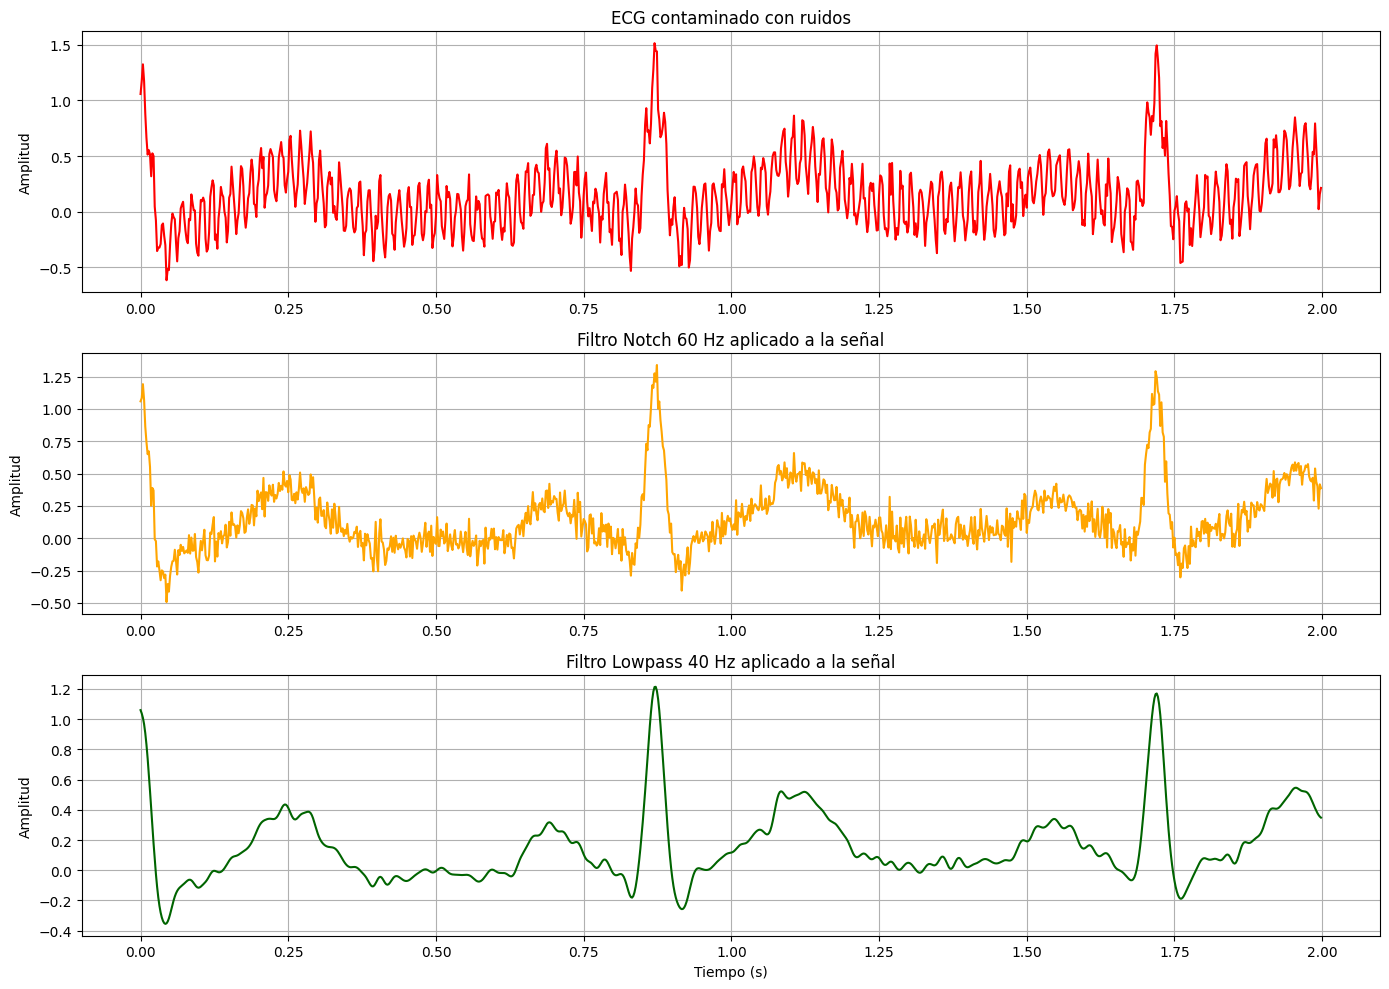

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import iirnotch, butter, filtfilt

#parametros de muestreo
fs = 500
duracion = 5
t = np.arange(0, duracion, 1/fs)

#ECG limpio con neurokit2
ecg_limpio = nk.ecg_simulate(duration=duracion, sampling_rate=int(fs), noise=0, heart_rate=70)

#simular ruido de red electrica de 60 Hz
ruido_60hz = 0.25 * np.sin(2 * np.pi * 60 * t)

#simular ruido blanco
ruido_blanco = np.random.normal(0, 0.08, len(ecg_limpio))

#señal combinada final con ambos ruidos
ecg_ruidoso = ecg_limpio + ruido_60hz + ruido_blanco

#ETAPA 1: Eliminar interferencia electrica de 60 Hz
#usamos iirnotch con factor de calidad Q = 30
frecuencia_notch = 60
Q = 30
b_notch, a_notch = iirnotch(frecuencia_notch, Q, fs=fs)

#filtro 1 aplicado
ecg_sin_60hz = filtfilt(b_notch, a_notch, ecg_ruidoso)


#ETAPA 2: Eliminar ruido de alta frecuencia
#filtro Butterworth Lowpass con frecuencia de corte en 40 Hz
f_corte_low = 40.0
b_low, a_low = butter(N=4, Wn=f_corte_low, btype='low', fs=fs)

#filtro 2 aplicado
ecg_filtrado_final = filtfilt(b_low, a_low, ecg_sin_60hz)


#Mostrar los resultados
muestras_visibles = int(2 * fs)
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(t[:muestras_visibles], ecg_ruidoso[:muestras_visibles], color='red')
plt.title('ECG contaminado con ruidos')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(3, 1, 2)
plt.plot(t[:muestras_visibles], ecg_sin_60hz[:muestras_visibles], color='orange')
plt.title('Filtro Notch 60 Hz aplicado a la señal')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(3, 1, 3)
plt.plot(t[:muestras_visibles], ecg_filtrado_final[:muestras_visibles], color='darkgreen')
plt.title('Filtro Lowpass 40 Hz aplicado a la señal')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

**Actividad 5**

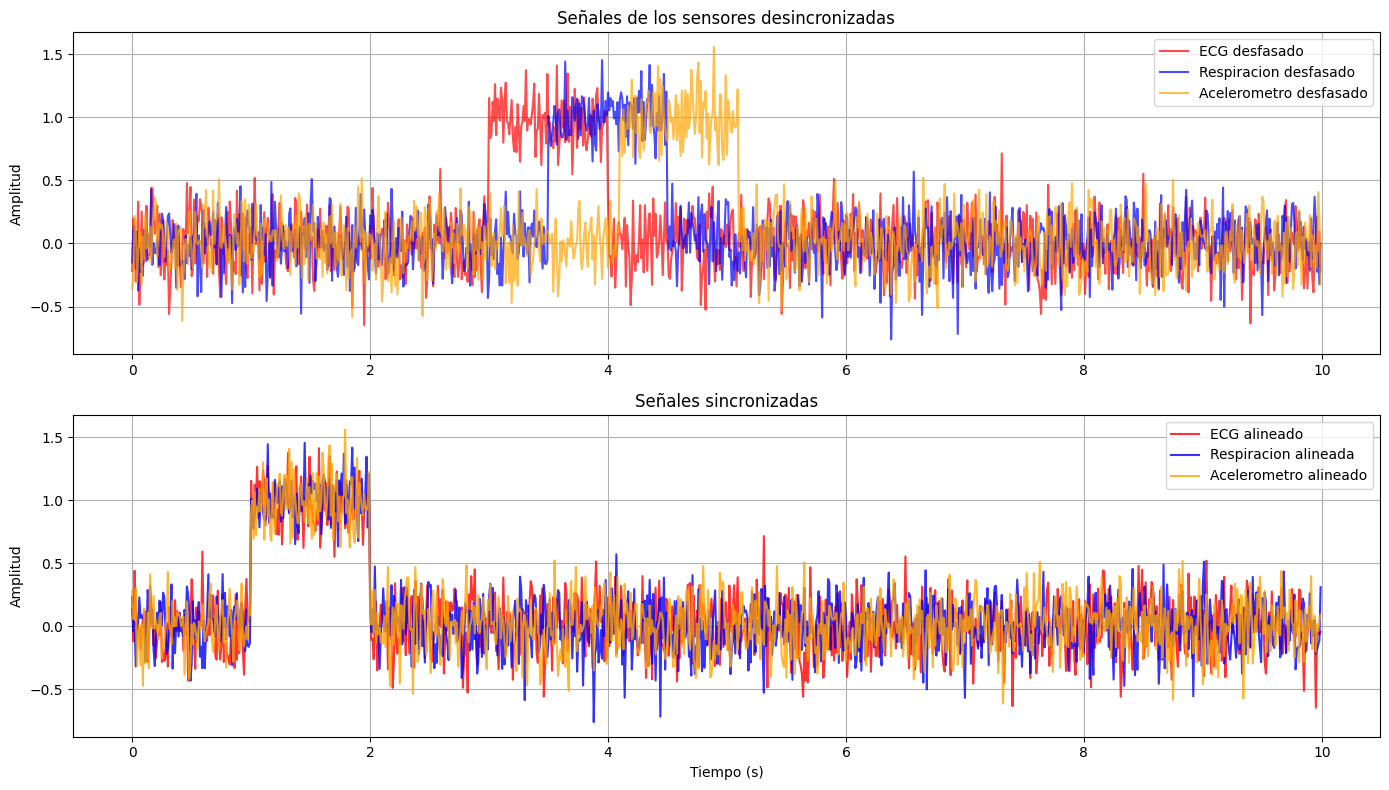

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

#parametros
fs = 100
duracion = 10
t = np.arange(0, duracion, 1/fs)
n_muestras = len(t)

#evento base que compartiran las tres señales
evento_base = np.zeros(n_muestras)
evento_base[int(1*fs):int(2*fs)] = 1.0

#resultados reproducibles de señales
np.random.seed(123)

#señal ECG con retraso de 2 segundos -> 2 * fs = 200 muestras
delay_ecg_real = int(2.0 * fs)
ecg_ruidoso = np.roll(evento_base, delay_ecg_real) + np.random.normal(0, 0.2, n_muestras)

#señal de respiracion con retraso de 2.5 segundos -> 2.5 * fs = 250 muestras
delay_resp_real = int(2.5 * fs)
#añadimos ruido gaussiano
resp_ruidosa = np.roll(evento_base, delay_resp_real) + np.random.normal(0, 0.2, n_muestras)

#señal acelerometro con retraso de 3.1 segundos -> 3.1 * fs = 310 muestras
delay_acc_real = int(3.1 * fs)
#añadimos ruido gausiano
acc_ruidosa = np.roll(evento_base, delay_acc_real) + np.random.normal(0, 0.2, n_muestras)

def alinear_senal(s_referencia, s_desplazada):
    #correlacion cruzada entre ambas señales
    corr = correlate(s_desplazada, s_referencia, mode='full')
    #encontrar el retraso estimado
    estimated_delay = np.argmax(corr) - (len(s_referencia) - 1)
    #corregir el desfase de la señal
    s_sincronizada = np.roll(s_desplazada, -estimated_delay)

    return estimated_delay, s_sincronizada

#sincronizamos cada uno de los sensores
delay_ecg, ecg_sincronizado = alinear_senal(evento_base, ecg_ruidoso)
delay_resp, resp_sincronizada = alinear_senal(evento_base, resp_ruidosa)
delay_acc, acc_sincronizado = alinear_senal(evento_base, acc_ruidosa)


#Mostrar los resultados
plt.figure(figsize=(14, 8))

#sensores desincronizados
plt.subplot(2, 1, 1)
plt.plot(t, ecg_ruidoso, label='ECG desfasado', color='red', alpha=0.7)
plt.plot(t, resp_ruidosa, label='Respiracion desfasado', color='blue', alpha=0.7)
plt.plot(t, acc_ruidosa, label='Acelerometro desfasado', color='orange', alpha=0.7)
plt.title('Señales de los sensores desincronizadas')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()

#Sensores sincronizados
plt.subplot(2, 1, 2)
plt.plot(t, ecg_sincronizado, label='ECG alineado', color='red', alpha=0.8)
plt.plot(t, resp_sincronizada, label='Respiracion alineada', color='blue', alpha=0.8)
plt.plot(t, acc_sincronizado, label='Acelerometro alineado', color='orange', alpha=0.8)
plt.title('Señales sincronizadas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Actividad 6**

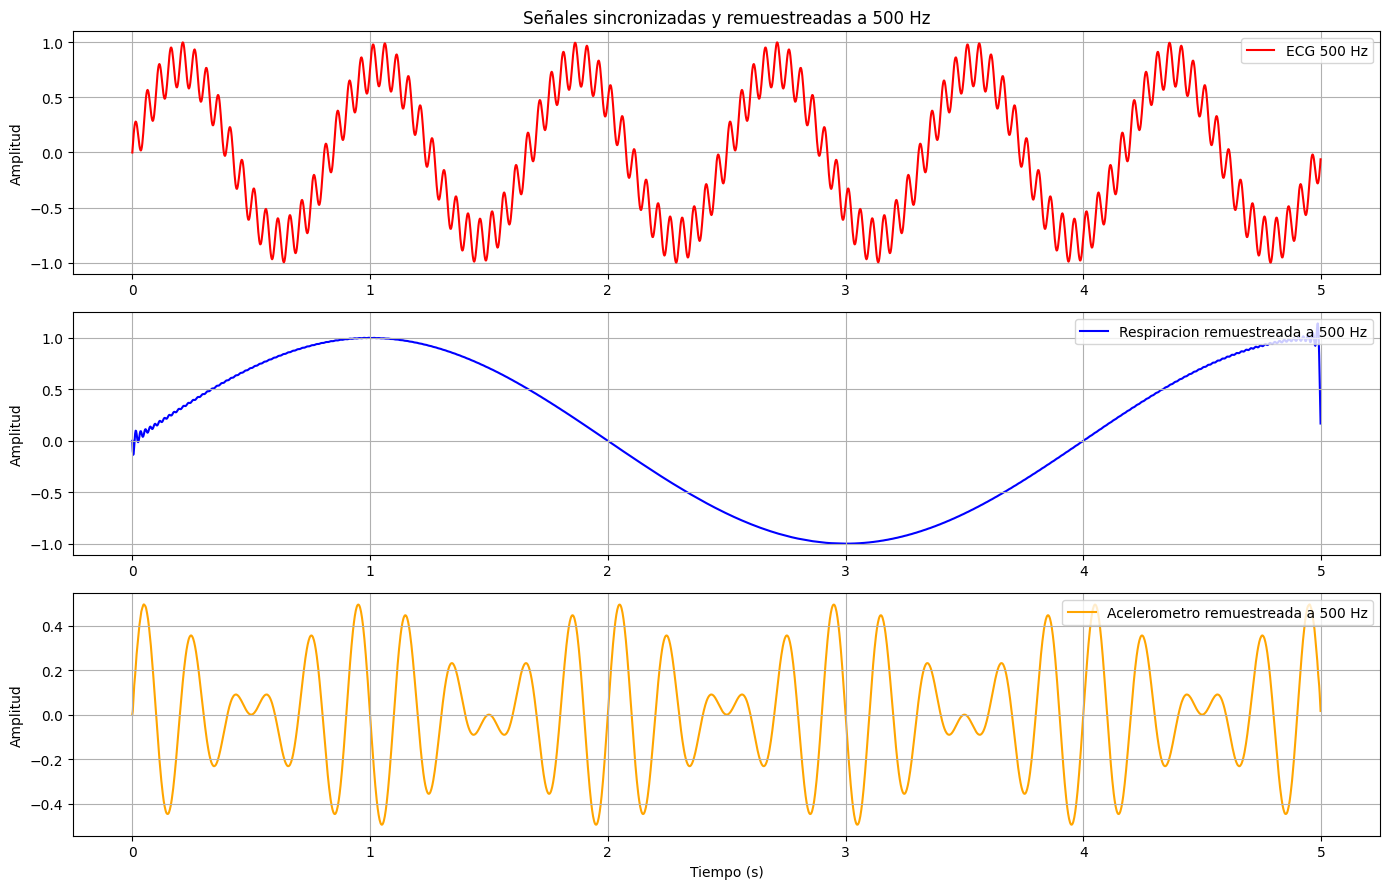

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

#duracion de la señal
duracion = 5

#señal ECG a 500 Hz
fs_ecg = 500
t_ecg = np.arange(0, duracion, 1/fs_ecg)
ecg_500hz = 0.8 * np.sin(2 * np.pi * 1.2 * t_ecg) + 0.2 * np.sin(2 * np.pi * 20 * t_ecg)

#señal respiración a 100 Hz
fs_resp = 100
t_resp = np.arange(0, duracion, 1/fs_resp)
resp_100hz = np.sin(2 * np.pi * 0.25 * t_resp)

#simular acelerometro a 200 Hz
fs_acc = 200
t_acc = np.arange(0, duracion, 1/fs_acc)
acc_200hz = 0.5 * np.cos(2 * np.pi * 0.5 * t_acc) * np.sin(2 * np.pi * 5 * t_acc)

#llevar señales a 500Hz del ECG
n_objetivo = len(ecg_500hz)

#remuestreo de la respiración de 100 Hz a 500 Hz
resp_500hz = resample(resp_100hz, n_objetivo)

#remuestreo del acelerometro de 200 Hz a 500 Hz
acc_500hz = resample(acc_200hz, n_objetivo)


plt.figure(figsize=(14, 9))

#señal referencia de ECG 500Hz
plt.subplot(3, 1, 1)
plt.plot(t_ecg, ecg_500hz, color='red', label='ECG 500 Hz')
plt.title('Señales sincronizadas y remuestreadas a 500 Hz')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')

#señal remuestreada de respiracion a 500hz
plt.subplot(3, 1, 2)
plt.plot(t_ecg, resp_500hz, color='blue', label='Respiracion remuestreada a 500 Hz', zorder=1)
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')

#señal remuestreada de acelerometro a 500hz
plt.subplot(3, 1, 3)
plt.plot(t_ecg, acc_500hz, color='orange', label='Acelerometro remuestreada a 500 Hz', zorder=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
